In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from pprint import pprint
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
%matplotlib inline

In [4]:
cwd = Path.cwd()
project_root = cwd.parent
data_path = project_root / "data" / "Online Retail.xlsx"

In [5]:
data = pd.ExcelFile(str(data_path))
data.sheet_names

['Online Retail']

In [6]:
data = data.parse("Online Retail")

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [8]:
data = data[data["Quantity"] > 0]

In [9]:
latest_date = max(data["InvoiceDate"])
latest_date

Timestamp('2011-12-09 12:50:00')

In [10]:
threshold_time = latest_date - pd.Timedelta(days=45)

In [11]:
cus_latest_date = data.groupby("CustomerID")["InvoiceDate"].max()
cus_latest_date.head()

CustomerID
12346.0   2011-01-18 10:01:00
12347.0   2011-12-07 15:52:00
12348.0   2011-09-25 13:13:00
12349.0   2011-11-21 09:51:00
12350.0   2011-02-02 16:01:00
Name: InvoiceDate, dtype: datetime64[us]

In [12]:
target = np.where(cus_latest_date > threshold_time, 1, 0)
target

array([0, 1, 0, ..., 1, 1, 1], shape=(4339,))

In [13]:
t_data = data[data["InvoiceDate"] < threshold_time]

In [14]:
customers_u_data = pd.read_csv(project_root / "data" / "customers_u_data.csv")

In [15]:
customers_u_data.columns

Index(['CustomerID', 'Recency', 'Frequency', 'MoneySpent', 'Cluster'], dtype='str')

In [16]:
customers_u_data["CustomerID"]

0       12346.0
1       12347.0
2       12348.0
3       12350.0
4       12352.0
         ...   
3896    18280.0
3897    18281.0
3898    18282.0
3899    18283.0
3900    18287.0
Name: CustomerID, Length: 3901, dtype: float64

In [17]:
indexes = cus_latest_date.index.get_indexer(customers_u_data["CustomerID"])
indexes = indexes[indexes != -1]

In [18]:
customers_u_data["WillBuy"] = target[indexes]

In [19]:
classes_count = customers_u_data["WillBuy"].value_counts()
(classes_count/classes_count.sum(axis=0))*100

WillBuy
0    58.241477
1    41.758523
Name: count, dtype: float64

In [20]:
customers_u_data.shape

(3901, 6)

In [21]:
customers_u_data_copy = customers_u_data.copy()

In [22]:
X = customers_u_data_copy[['Recency', 'Frequency', 'MoneySpent', 'Cluster']].to_numpy()
Y = customers_u_data_copy["WillBuy"].to_numpy()

In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=101, shuffle=True)

In [24]:
# Fitting the model
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X=X_train, y=Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [25]:
y_train_pred = decision_tree.predict(X_train)
y_test_pred = decision_tree.predict(X_test)

train_acc = accuracy_score(y_true=Y_train, y_pred=y_train_pred)
test_acc = accuracy_score(y_true=Y_test, y_pred=y_test_pred)

In [26]:
train_acc, test_acc

(1.0, 0.614596670934699)

In [27]:
train_conf_mat = confusion_matrix(y_true=Y_train, y_pred=y_train_pred)
test_conf_mat = confusion_matrix(y_true=Y_test, y_pred=y_test_pred)

train_conf_mat, test_conf_mat

(array([[1812,    0],
        [   0, 1308]]),
 array([[307, 153],
        [148, 173]]))

In [28]:
train_f1_score = f1_score(y_true=Y_train, y_pred=y_train_pred)
test_f1_score = f1_score(y_true=Y_test, y_pred=y_test_pred)

train_f1_score, test_f1_score

(1.0, 0.5347758887171561)

In [29]:
train_report = classification_report(y_true=Y_train, y_pred=y_train_pred)
test_report = classification_report(y_true=Y_test, y_pred=y_test_pred)

In [30]:
print(train_report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1812
           1       1.00      1.00      1.00      1308

    accuracy                           1.00      3120
   macro avg       1.00      1.00      1.00      3120
weighted avg       1.00      1.00      1.00      3120



In [31]:
print(test_report)

              precision    recall  f1-score   support

           0       0.67      0.67      0.67       460
           1       0.53      0.54      0.53       321

    accuracy                           0.61       781
   macro avg       0.60      0.60      0.60       781
weighted avg       0.62      0.61      0.62       781



##### Hyperparameter Tuning

In [32]:
max_depths = [i for i in range(2,10)]
train_reports = []
test_reports = []

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, Y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_report = classification_report(y_true=Y_train, y_pred=y_train_pred)
    test_report = classification_report(y_true=Y_test, y_pred=y_test_pred)

    train_reports.append(train_report)
    test_reports.append(test_report)

In [33]:
for report in train_reports:
    print(report)

              precision    recall  f1-score   support

           0       0.73      0.73      0.73      1812
           1       0.62      0.63      0.62      1308

    accuracy                           0.68      3120
   macro avg       0.68      0.68      0.68      3120
weighted avg       0.68      0.68      0.68      3120

              precision    recall  f1-score   support

           0       0.72      0.81      0.76      1812
           1       0.68      0.56      0.61      1308

    accuracy                           0.70      3120
   macro avg       0.70      0.68      0.69      3120
weighted avg       0.70      0.70      0.70      3120

              precision    recall  f1-score   support

           0       0.73      0.79      0.76      1812
           1       0.67      0.60      0.64      1308

    accuracy                           0.71      3120
   macro avg       0.70      0.69      0.70      3120
weighted avg       0.71      0.71      0.71      3120

              preci

In [34]:
for report in test_reports:
    print(report)

              precision    recall  f1-score   support

           0       0.73      0.76      0.74       460
           1       0.63      0.59      0.61       321

    accuracy                           0.69       781
   macro avg       0.68      0.68      0.68       781
weighted avg       0.69      0.69      0.69       781

              precision    recall  f1-score   support

           0       0.71      0.82      0.76       460
           1       0.66      0.51      0.58       321

    accuracy                           0.69       781
   macro avg       0.68      0.66      0.67       781
weighted avg       0.69      0.69      0.68       781

              precision    recall  f1-score   support

           0       0.71      0.77      0.74       460
           1       0.62      0.54      0.58       321

    accuracy                           0.67       781
   macro avg       0.66      0.65      0.66       781
weighted avg       0.67      0.67      0.67       781

              preci

In [35]:
max_depths = [i for i in range(2,10)]
train_accs = []
test_accs = []

train_conf_mats = []
test_conf_mats = []

train_f1_scores = []
test_f1_scores = []

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, Y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_acc = accuracy_score(y_true=Y_train, y_pred=y_train_pred)
    test_acc = accuracy_score(y_true=Y_test, y_pred=y_test_pred)
    train_conf_mat = confusion_matrix(y_true=Y_train, y_pred=y_train_pred)
    test_conf_mat = confusion_matrix(y_true=Y_test, y_pred=y_test_pred)
    train_f1_score = f1_score(y_true=Y_train, y_pred=y_train_pred)
    test_f1_score = f1_score(y_true=Y_test, y_pred=y_test_pred)

    train_accs.append(train_acc)
    test_accs.append(test_acc)
    train_conf_mats.append(train_conf_mat)
    test_conf_mats.append(test_conf_mat)
    train_f1_scores.append(train_f1_score)
    test_f1_scores.append(test_f1_score)

Text(0, 0.5, 'Train accuracy')

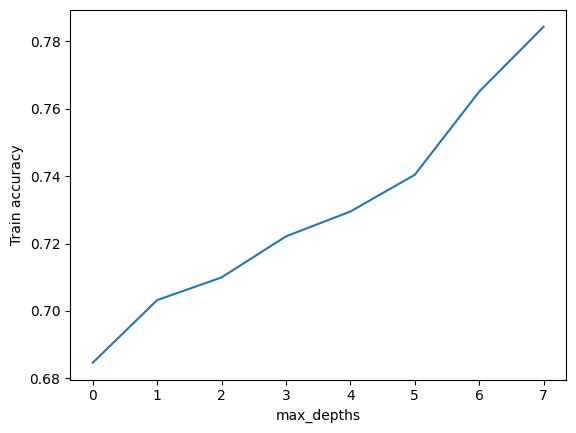

In [36]:
plt.plot(train_accs);
plt.xlabel("max_depths")
plt.ylabel("Train accuracy")

Text(0, 0.5, 'Test accuracy')

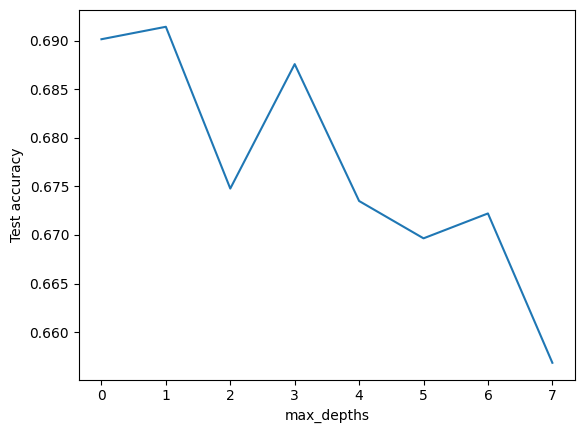

In [37]:
plt.plot(test_accs);
plt.xlabel("max_depths")
plt.ylabel("Test accuracy")

Text(0, 0.5, 'Train f1 scores')

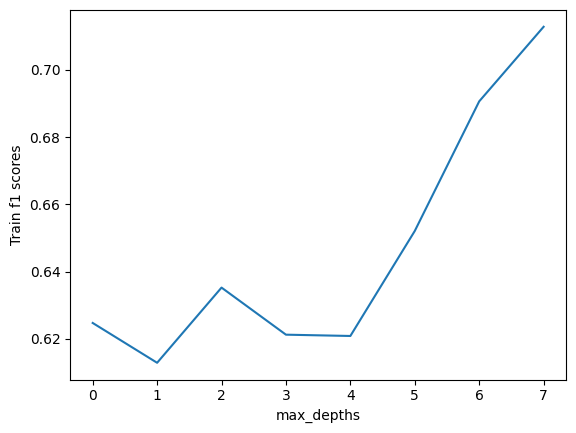

In [38]:
plt.plot(train_f1_scores);
plt.xlabel("max_depths")
plt.ylabel("Train f1 scores")

Text(0, 0.5, 'Test f1 scores')

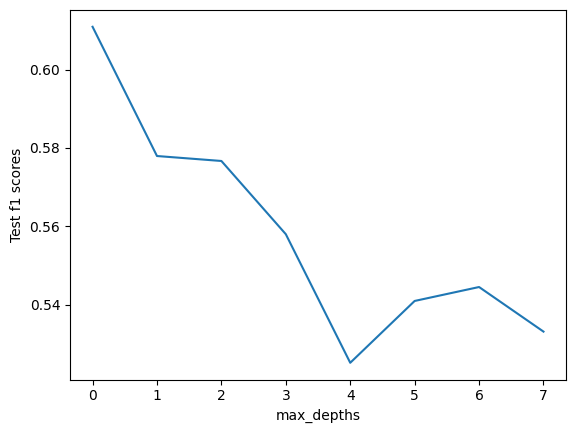

In [39]:
plt.plot(test_f1_scores);
plt.xlabel("max_depths")
plt.ylabel("Test f1 scores")

In [40]:
decision_tree = DecisionTreeClassifier(max_depth=3, class_weight="balanced")
decision_tree.fit(X_train, Y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_acc = accuracy_score(y_true=Y_train, y_pred=y_train_pred)
test_acc = accuracy_score(y_true=Y_test, y_pred=y_test_pred)
train_conf_mat = confusion_matrix(y_true=Y_train, y_pred=y_train_pred)
test_conf_mat = confusion_matrix(y_true=Y_test, y_pred=y_test_pred)
train_f1_score = f1_score(y_true=Y_train, y_pred=y_train_pred)
test_f1_score = f1_score(y_true=Y_test, y_pred=y_test_pred)

In [41]:
train_acc, test_acc

(0.7842948717948718, 0.6568501920614597)

In [42]:
train_conf_mat, test_conf_mat

(array([[1612,  200],
        [ 473,  835]]),
 array([[360, 100],
        [168, 153]]))

In [43]:
train_f1_score, test_f1_score

(0.7127614169867691, 0.5331010452961672)

### Let's try Random Forest

In [44]:
rfmodel = RandomForestClassifier(class_weight="balanced")
rfmodel.fit(X_train, Y_train)

y_train_pred = rfmodel.predict(X_train)
y_test_pred = rfmodel.predict(X_test)

train_acc = accuracy_score(y_true=Y_train, y_pred=y_train_pred)
test_acc = accuracy_score(y_true=Y_test, y_pred=y_test_pred)
train_conf_mat = confusion_matrix(y_true=Y_train, y_pred=y_train_pred)
test_conf_mat = confusion_matrix(y_true=Y_test, y_pred=y_test_pred)
train_f1_score = f1_score(y_true=Y_train, y_pred=y_train_pred)
test_f1_score = f1_score(y_true=Y_test, y_pred=y_test_pred)

In [45]:
train_acc, test_acc

(1.0, 0.6632522407170295)

In [46]:
train_f1_score, test_f1_score

(1.0, 0.559463986599665)

In [47]:
max_depths = [i for i in range(2,11)]
train_accs = []
test_accs = []

train_conf_mats = []
test_conf_mats = []

train_f1_scores = []
test_f1_scores = []

for depth in max_depths:
    rfmodel = RandomForestClassifier(max_depth=depth, class_weight="balanced")
    rfmodel.fit(X_train, Y_train)
    y_train_pred = rfmodel.predict(X_train)
    y_test_pred = rfmodel.predict(X_test)
    train_acc = accuracy_score(y_true=Y_train, y_pred=y_train_pred)
    test_acc = accuracy_score(y_true=Y_test, y_pred=y_test_pred)
    train_conf_mat = confusion_matrix(y_true=Y_train, y_pred=y_train_pred)
    test_conf_mat = confusion_matrix(y_true=Y_test, y_pred=y_test_pred)
    train_f1_score = f1_score(y_true=Y_train, y_pred=y_train_pred)
    test_f1_score = f1_score(y_true=Y_test, y_pred=y_test_pred)

    train_accs.append(train_acc)
    test_accs.append(test_acc)
    train_conf_mats.append(train_conf_mat)
    test_conf_mats.append(test_conf_mat)
    train_f1_scores.append(train_f1_score)
    test_f1_scores.append(test_f1_score)

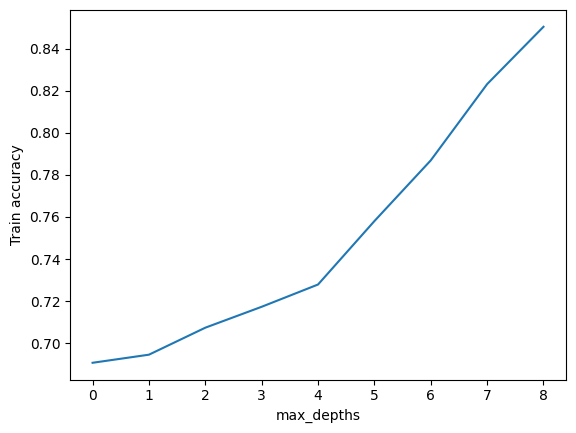

In [48]:
plt.plot(train_accs)
plt.xlabel("max_depths")
plt.ylabel("Train accuracy");

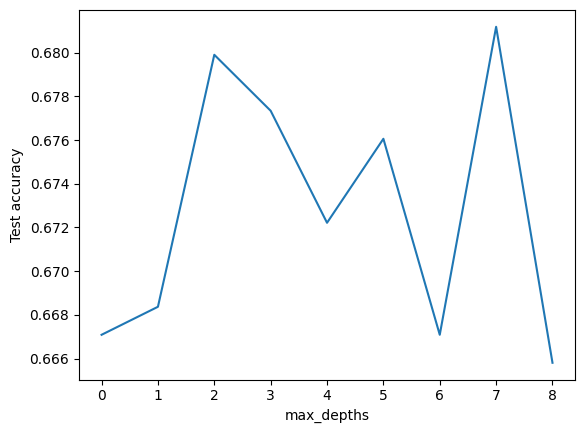

In [49]:
plt.plot(test_accs)
plt.xlabel("max_depths")
plt.ylabel("Test accuracy");

Text(0, 0.5, 'Train f1 scores')

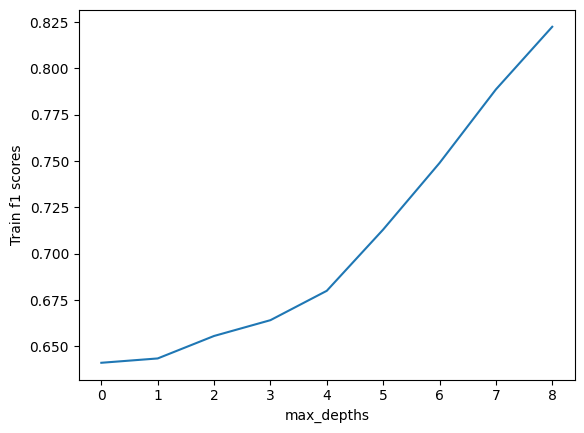

In [50]:
plt.plot(train_f1_scores)
plt.xlabel("max_depths")
plt.ylabel("Train f1 scores")

Text(0, 0.5, 'Test f1 scores')

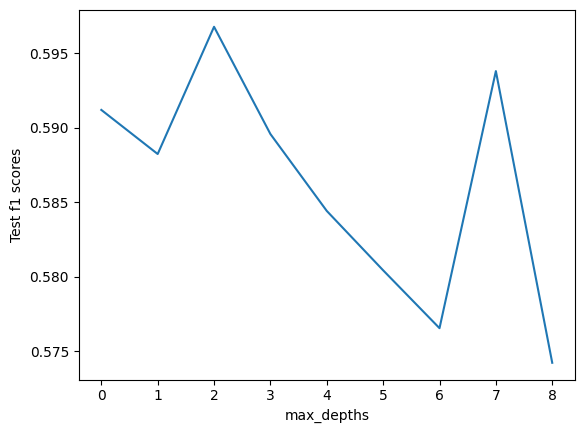

In [51]:
plt.plot(test_f1_scores);
plt.xlabel("max_depths")
plt.ylabel("Test f1 scores")

In [52]:
best_model = RandomForestClassifier(max_depth=4, class_weight="balanced")
best_model.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [53]:
best_model.feature_importances_

array([0.18024196, 0.46276146, 0.29743216, 0.05956442])

In [54]:
customers_u_data.columns

Index(['CustomerID', 'Recency', 'Frequency', 'MoneySpent', 'Cluster',
       'WillBuy'],
      dtype='str')

In [55]:
customers_u_data.to_csv(project_root / "data" / "rfm_features_with_targets.csv", index=False)